In [4]:
# Təqdim edilən CSV faylı oxuyun.

In [5]:
import pandas as pd
df = pd.read_csv('complex_dataframe.csv')
print(df.head())

   Product_ID     Category   Price  Units_Sold  Store_ID  Customer_Age  \
0           1         Food  350.59          48        12            40   
1           2    Furniture  270.37          66        16            56   
2           3  Electronics  158.22          70         1            34   
3           4         Food  407.83          28         3            51   
4           5         Food  343.94          93        20            58   

  Customer_Gender  Discount_Applied Purchase_Date  Satisfaction_Score  
0            Male                 5    2022-01-01                   2  
1            Male                 5    2022-01-02                   2  
2          Female                 0    2022-01-03                   3  
3            Male                 5    2022-01-04                   5  
4            Male                20    2022-01-05                   5  


In [6]:
# 1. Müştəri məmnuniyyəti (Satisfaction_Score) 4-dən yuxarı olan müştərilərin ortalama yaşı nə qədərdir?

In [7]:
print(f'Average age: {df['Customer_Age'][df['Satisfaction_Score'] > 4].mean()}')

Average age: 41.839622641509436


In [8]:
# 2. Müştəri yaşları (Customer_Age) üzrə ortalama, median və standart deviation hesablayın.

In [9]:
print(f'Mean: {df['Customer_Age'].mean()}')
print(f'Median: {df['Customer_Age'].median()}')
print(f'Std: {df['Customer_Age'].std()}')

Mean: 43.31
Median: 43.0
Std: 14.89052140214128


In [10]:
# 3. Satılan vahidlərin (Units_Sold) 90-cı percentilini tapın.

In [11]:
print(f'90 percetile: {df['Units_Sold'].quantile(0.9)}')

90 percetile: 89.0


In [12]:
# 4. Satılan məhsul qiymətlərində (Price) ekstremal dəyərləri (outliers) tapmaq üçün IQR metodundan istifadə edin.

In [13]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
higher_bound = Q3 + 1.5 * IQR
outliers = df['Price'][(df['Price'] < lower_bound) | (df['Price'] > higher_bound)]
print(outliers)

Series([], Name: Price, dtype: float64)


In [14]:
# 5. Müştəri məmnuniyyət göstəricisinin (Satisfaction_Score) paylanmasını göstərən histogram yaradın.

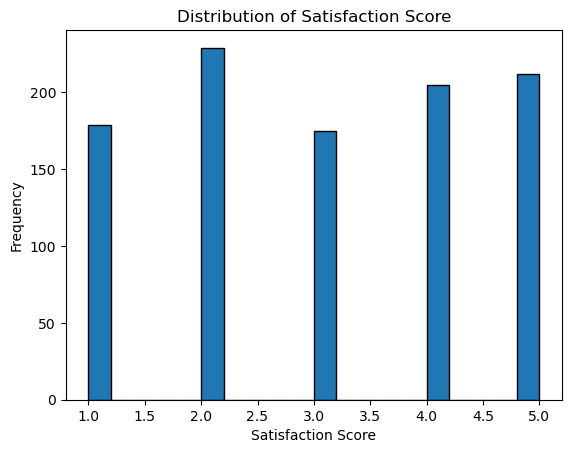

In [18]:
import matplotlib.pyplot as plt
plt.hist(df['Satisfaction_Score'], bins=20, edgecolor='black')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')
plt.title('Distribution of Satisfaction Score')
plt.show()

In [37]:
# 6. Müxtəlif kateqoriyaların ortalama qiymətlərini müqayisə edin və ANOVA testi tətbiq edin.

In [35]:
from scipy.stats import f_oneway
food = df['Price'][df['Category'] == 'Food']
furniture = df['Price'][df['Category'] == 'Furniture']
electronics = df['Price'][df['Category'] == 'Electronics']
f, p = f_oneway(food, furniture, electronics)
print(p)

0.7960976029980998


In [36]:
# 7. Chi-Square testi ilə müştəri cinsiyyəti və məmnuniyyət göstəricisi arasında əlaqəni yoxlayın.

In [38]:
from scipy.stats import chi2_contingency
crosstab = pd.crosstab(df['Customer_Gender'], df['Satisfaction_Score'])
chi = chi2_contingency(crosstab)
print(chi)

Chi2ContingencyResult(statistic=np.float64(2.0788410165225866), pvalue=np.float64(0.7212605705897106), dof=4, expected_freq=array([[ 90.574, 115.874,  88.55 , 103.73 , 107.272],
       [ 88.426, 113.126,  86.45 , 101.27 , 104.728]]))


In [41]:
# 8.T-test istifadə edərək Electronics və Clothing kateqoriyalarında məmnuniyyət fərqini yoxlayın.

In [40]:
from scipy.stats import ttest_ind
elec = df['Satisfaction_Score'][df['Category'] == 'Electronics']
cloth = df['Satisfaction_Score'][df['Category'] == 'Clothing']
ttest = ttest_ind(elec, cloth)
print(ttest)

TtestResult(statistic=np.float64(-0.2544307659815514), pvalue=np.float64(0.7992704018815161), df=np.float64(486.0))


In [27]:
# 9. Müştərinin yaşı 30-dan yuxarı olma ehtimalını hesablayın.

In [45]:
print(f'Prob over 30: {(len(df['Customer_Age'][df['Customer_Age'] > 30]))/(len(df['Customer_Age']))}')

Prob over 30: 0.753


In [46]:
# 10. Endirim tətbiq edilən məhsulun Electronics kateqoriyasına aid olma ehtimalını hesablayın.

In [58]:
print(f'Prob disc applied: {len(df['Category'][(df['Category'] == 'Electronics') & (df['Discount_Applied'] != 0)])/len(df['Category'][df['Category'] == 'Electronics'])}')

Prob disc applied: 0.7945736434108527


In [33]:
# 11.  Müxtəlif mağazalar üzrə ümumi gəliri hesablayan funksiya yazın.

In [59]:
def total(store_id):
    df['Revenue'] = df['Price'] * df['Units_Sold'] * (1 - df['Discount_Applied']/100)
    total_revenue = df[df['Store_ID'] == store_id]['Revenue'].sum()
    print(total_revenue)
total(12)

604637.7415


In [31]:
# 12. Satış tarixinə görə hər bir kateqoriya üzrə orta satış həcmini göstərən pivot cədvəl yaradın.

In [60]:
pivot_table = pd.pivot_table(df, values='Units_Sold', index='Purchase_Date', columns='Category', aggfunc='mean', fill_value=0)
print(pivot_table)

Category       Clothing  Electronics  Food  Furniture
Purchase_Date                                        
2022-01-01          0.0          0.0  48.0        0.0
2022-01-02          0.0          0.0   0.0       66.0
2022-01-03          0.0         70.0   0.0        0.0
2022-01-04          0.0          0.0  28.0        0.0
2022-01-05          0.0          0.0  93.0        0.0
...                 ...          ...   ...        ...
2024-09-22          0.0         85.0   0.0        0.0
2024-09-23          0.0         88.0   0.0        0.0
2024-09-24          0.0          0.0   0.0       98.0
2024-09-25          0.0          0.0   0.0       86.0
2024-09-26          0.0          0.0   3.0        0.0

[1000 rows x 4 columns]


In [35]:
# 13. Minimum, maksimum və orta qiymətləri göstərən funksiya yazın.

In [61]:
def minmaxavg():
    print(f'Max price: {df['Price'].max()}')
    print(f'Min price: {df['Price'].min()}')
    print(f'Avg price: {df['Price'].mean()}')
minmaxavg()

Max price: 499.86
Min price: 7.29
Avg price: 252.37873000000002


In [15]:
# 14.Məhsulun qiymətləri və satılan vahidlər arasında regresiya analizi aparın.

In [63]:
#???